<a href="https://colab.research.google.com/github/nguyenbao-sca/thuc_hanh_git/blob/main/NumPy_and_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A. Thực hành NumPy


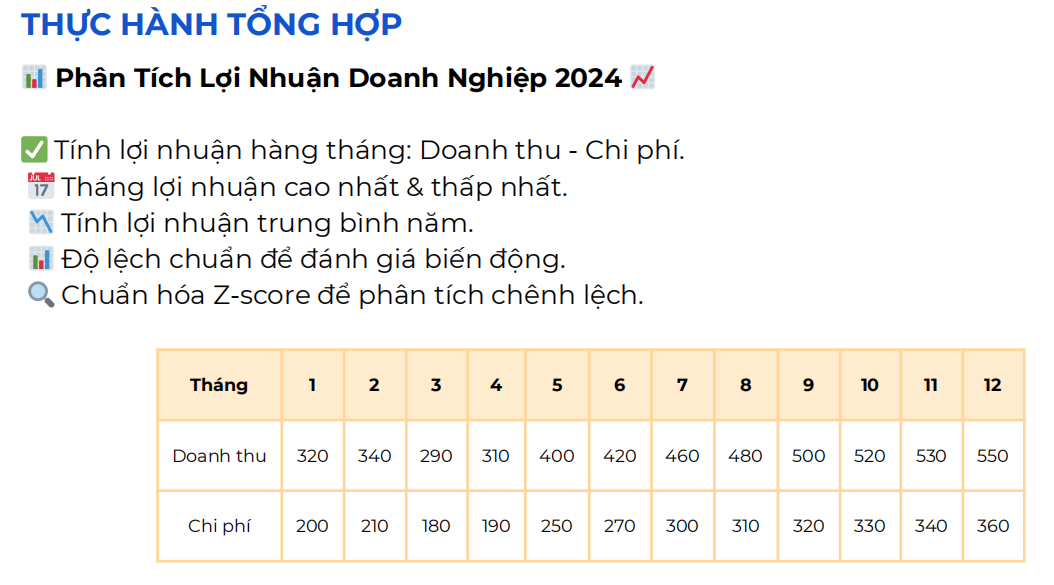

In [ ]:
import numpy as np
path= r"/content/drive/MyDrive/0. Learning Python/Moudule 3/Numpy.csv" #raw
data= np.loadtxt(path, delimiter=",", skiprows=1, encoding= "latin1") #encoding= "latin1" nhằm xử lý lỗi urtf8
print(data)


[[  1. 320. 200.]
 [  2. 340. 210.]
 [  3. 290. 180.]
 [  4. 310. 190.]
 [  5. 400. 250.]
 [  6. 420. 270.]
 [  7. 460. 300.]
 [  8. 480. 310.]
 [  9. 500. 320.]
 [ 10. 520. 330.]
 [ 11. 530. 340.]
 [ 12. 550. 360.]]


## Câu 1. Tính lợi nhuận hàng tháng

In [ ]:
thang= data[:, 0]
doanh_thu= data[:, 1]
chi_phi= data[:, 2]
loi_nhuan= doanh_thu-chi_phi
print(loi_nhuan)

[120. 130. 110. 120. 150. 150. 160. 170. 180. 190. 190. 190.]


## Câu 2. Tìm tháng có lợi nhuận cao nhất và thấp nhất


In [ ]:
# 1. Xác đinh lợi nhuận max/min
loi_nhuan_max= np.max(loi_nhuan)
loi_nhuan_min= np.min(loi_nhuan)
# 2. Xác định tháng (vị trí) có lợi nhuận max/min
vi_tri_max= np.where(loi_nhuan== loi_nhuan_max)
vi_tri_min= np.where(loi_nhuan== loi_nhuan_min)
print("Tháng có lợi nhuận lớn nhất: ", thang[vi_tri_max])
print("Tháng có lợi nhuận thấp nhất", thang[vi_tri_min])

Tháng có lợi nhuận lớn nhất:  [10. 11. 12.]
Tháng có lợi nhuận thấp nhất [3.]
Lợi nhuận trung bình 1 năm:  155.0


## Câu 3. Tính lợi nhuận TB 1 năm

In [ ]:
loi_nhuan_TB= np.mean(loi_nhuan)
print("Lợi nhuận trung bình 1 năm: ", loi_nhuan_TB)

## Câu 4. Tính độ lệch chuẩn của lợi nhuận

In [ ]:
loi_nhuan_std= np.std(loi_nhuan)
print(f"Độ lệch chuẩn của lợi nhuận: {loi_nhuan_std:.2f}")

Độ lệch chuẩn của lợi nhuận: 28.43


## Câu 5. Tính Z-score của lợi nhuận
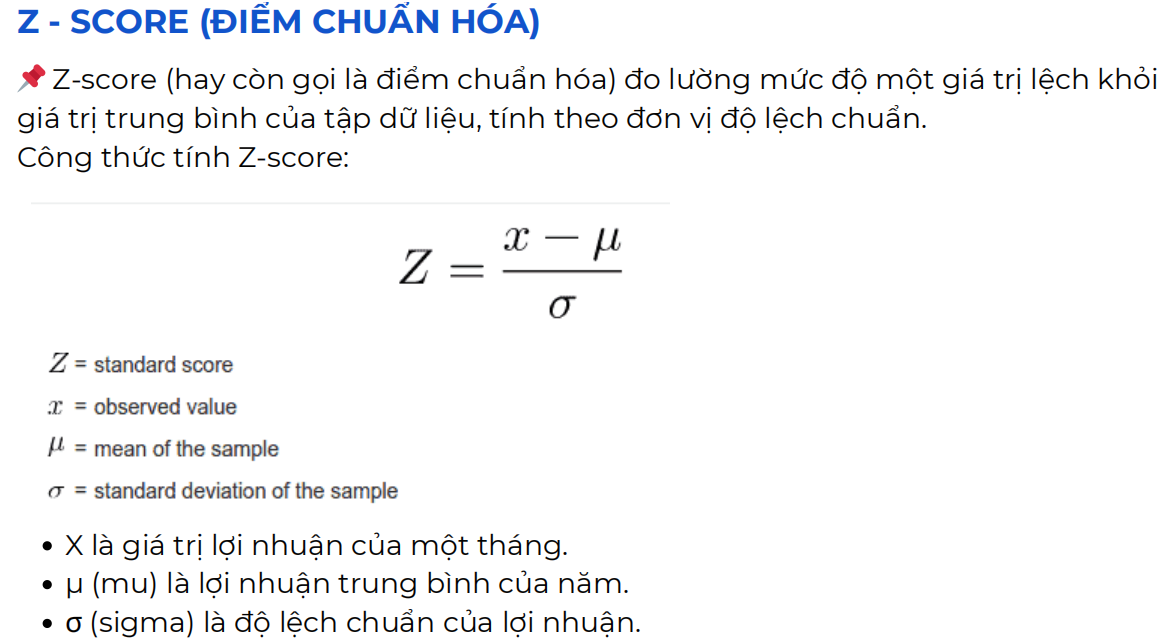
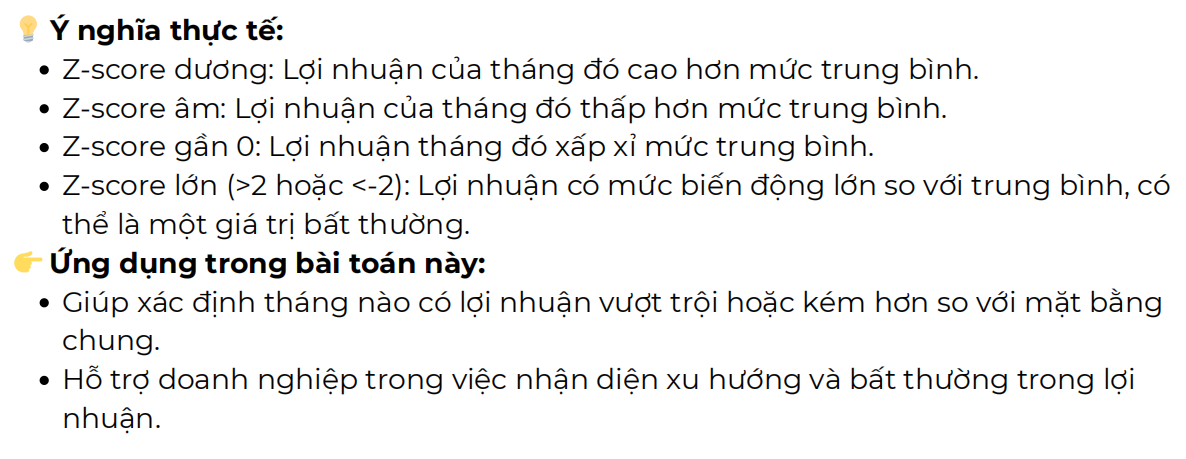

In [ ]:
Z_score_loi_nhuan= (loi_nhuan- loi_nhuan_TB)/loi_nhuan_std
Z_score_loi_nhuan

array([-1.2310418 , -0.87931557, -1.58276803, -1.2310418 , -0.17586311,
       -0.17586311,  0.17586311,  0.52758934,  0.87931557,  1.2310418 ,
        1.2310418 ,  1.2310418 ])

## Xuất ra kết quả của phân tích


In [ ]:
# Xuất ra kết quả quan trọng: Tháng, Lợi nhuận, Z-score
output_data= np.column_stack((thang, loi_nhuan, Z_score_loi_nhuan))
print(output_data)

[[ 1.00000000e+00  1.20000000e+02 -1.23104180e+00]
 [ 2.00000000e+00  1.30000000e+02 -8.79315573e-01]
 [ 3.00000000e+00  1.10000000e+02 -1.58276803e+00]
 [ 4.00000000e+00  1.20000000e+02 -1.23104180e+00]
 [ 5.00000000e+00  1.50000000e+02 -1.75863115e-01]
 [ 6.00000000e+00  1.50000000e+02 -1.75863115e-01]
 [ 7.00000000e+00  1.60000000e+02  1.75863115e-01]
 [ 8.00000000e+00  1.70000000e+02  5.27589344e-01]
 [ 9.00000000e+00  1.80000000e+02  8.79315573e-01]
 [ 1.00000000e+01  1.90000000e+02  1.23104180e+00]
 [ 1.10000000e+01  1.90000000e+02  1.23104180e+00]
 [ 1.20000000e+01  1.90000000e+02  1.23104180e+00]]


In [ ]:
# Lưu kết quả
np.savetxt(
    "output_data.csv" #tên file + đuôi file (.csv)
    , output_data # dữ liệu đã được xử lý
    , delimiter="," # thêm phần ngăn cách dấu "," giữa các giá trị
    , header= "Tháng,Lợi nhuận,Z-score" # thêm tiêu đề cho các cột
    , comments= " "
    , fmt= "%d, %.2f, %.2f" # %d - số nguyên | %.2f- float (làm tròn đến 2 số thập phân sau dấu ,
)

# B. Thực hành Pandas


## 1. Đọc và ghi dữ liệu trong pandas (csv, excel, sql)

In [ ]:
# Đọc và xuất file CSV
import pandas as pd
path= r"/content/drive/MyDrive/0. Learning Python/Moudule 3/Numpy.csv"
df= pd.read_csv(path, encoding= "latin1")
df= df.replace(200,300)
df

,Tháng,Doanh thu,Chi phí
0,1,320,300
1,2,340,210
2,3,290,180
3,4,310,190
4,5,400,250
5,6,420,270
6,7,460,300
7,8,480,310
8,9,500,320
9,10,520,330


In [ ]:
# Xuất vào 1 specific folder trong gg drive
df.to_csv("/content/drive/MyDrive/0. Learning Python/Moudule 3/Dataset/financial_data_fix.csv", index=False) # "đường dẫn vào folder+ tên file"
# Tải xuống máy
df.to_csv("financial_data_fix.csv", index=False)
from google.colab import files
files.download("financial_data_fix.csv") #chỉ cần tên file là được

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Đọc và xuất file excel
df.to_excel("/content/drive/MyDrive/0. Learning Python/Moudule 3/Dataset/financial_data.xlsx"
            , sheet_name= "financial_data"
            , index= False)
df_xlsx= pd.read_excel("/content/drive/MyDrive/0. Learning Python/Moudule 3/Dataset/financial_data.xlsx")
df_xlsx

,Tháng,Doanh thu,Chi phí
0,1,320,300
1,2,340,210
2,3,290,180
3,4,310,190
4,5,400,250
5,6,420,270
6,7,460,300
7,8,480,310
8,9,500,320
9,10,520,330


In [ ]:
#Đọc và xuất thành dạng .db (SQL)
import sqlite3 as sql
# lưu trữ vào CSDL
conn= sql.connect("/content/drive/MyDrive/0. Learning Python/Moudule 3/Dataset/financial_data.db") #cú pháp kết nối tới..., nếu lát tải xuống chỉ cần ghi financial_data.db
df.to_sql("financial_data" #Tên bảng
          , conn #nơi kết nối tới
          , if_exists= "replace" #nếu bảng tồn tại thì ghi đè
          , index= False #bỏ chỉ mục
        )
# tải vào folder trong drive or tải xuống máy


12

In [ ]:
path_db= r"/content/drive/MyDrive/0. Learning Python/Moudule 3/Dataset/financial_data.db"
conn= sql.connect(path_db) ## cần chú ý đây là biến được truyền vào nên không có "" khác với đường dẫn
df_sql= pd.read_sql("SELECT * FROM financial_data", conn)
df_sql

,Tháng,Doanh thu,Chi phí
0,1,320,300
1,2,340,210
2,3,290,180
3,4,310,190
4,5,400,250
5,6,420,270
6,7,460,300
7,8,480,310
8,9,500,320
9,10,520,330


## 2.